In [1]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv('transactions_large.csv')

In [4]:
df.head()

,user_id,transaction_id,amount,transaction_date,category,city
0,103,100000,953,2024-02-27,food,Delhi
1,436,100001,1288,2024-03-18,travel,Pune
2,349,100002,1023,2024-03-15,shopping,Bangalore
3,271,100003,681,2024-02-11,travel,Delhi
4,107,100004,1967,2024-02-07,electronics,Bangalore


In [ ]:
Task 1: User-level metrics:
total spend
total transactions

In [5]:
df.groupby('user_id', as_index = False).agg(
    total_spend = ('amount','sum'),
    toal_transactions = ('transaction_id','count')
)

,user_id,total_spend,toal_transactions
0,1,10906,14
1,2,10971,10
2,3,7999,9
3,4,9533,10
4,5,16847,15
...,...,...,...
495,496,9908,8
496,497,13556,16
497,498,9782,9
498,499,11166,9


Task 2- Top 5 users

In [6]:
df.groupby('user_id', as_index = False).agg(
    total_spend = ('amount','sum')
).sort_values(by='total_spend', ascending=False).head(3)

,user_id,total_spend
38,39,23981
434,435,20845
187,188,20362


In [7]:
user_spend= df.groupby('user_id', as_index = False).agg(
    total_spend = ('amount','sum')
)
user_spend['rank'] = user_spend['total_spend'].rank(method='dense', ascending = False)

In [9]:
user_spend[user_spend['rank'] <=3]

,user_id,total_spend,rank
38,39,23981,1.0
187,188,20362,3.0
434,435,20845,2.0


In [11]:
user_spend.describe()

,user_id,total_spend,rank
count,500.000000,500.000000,500.000000
mean,250.500000,10310.292000,248.718000
std,144.481833,3769.000156,142.587745
min,1.000000,844.000000,1.000000
25%,125.750000,7657.250000,125.750000
50%,250.500000,10132.000000,249.500000
75%,375.250000,12612.500000,371.250000
max,500.000000,23981.000000,495.000000


In [15]:
#User segmentation (high/medium/low)

user_spend['user_type'] = user_spend['total_spend'].apply(
    lambda x: 'high' if x > 12612 else ('medium' if x > 7657 else 'low')
    )

In [16]:
user_spend

,user_id,total_spend,rank,user_type
0,1,10906,207.0,medium
1,2,10971,201.0,medium
2,3,7999,357.0,medium
3,4,9533,278.0,medium
4,5,16847,29.0,high
...,...,...,...,...
495,496,9908,258.0,medium
496,497,13556,108.0,high
497,498,9782,263.0,medium
498,499,11166,194.0,medium


In [19]:
user_spend.dtypes

user_id          int64
total_spend      int64
rank           float64
user_type          str
dtype: object

In [20]:
#using np 
conditions = [
    user_spend['total_spend'] > 20000,
    (user_spend['total_spend'] > 10000) & (user_spend['total_spend'] <= 20000),
    user_spend['total_spend'] <= 10000
]
choices = ['high','medium','low']

user_spend['user_type_n'] = np.select(conditions, choices, default='low')

In [ ]:
For continuous numeric segmentation, pd.cut() is cleaner and less error-prone, while np.select() is better for custom conditional logic

In [23]:
user_spend['user_type_n'] = pd.cut(
    user_spend['total_spend'],
    bins = [0,10000,20000,float('inf')],
    labels = ['low','medium','high']
)

In [ ]:
Distribution of users by segment

In [24]:
user_spend['user_type_n'].value_counts()

user_type_n
medium    251
low       246
high        3
Name: count, dtype: int64

In [27]:
user_spend.groupby('user_type_n',as_index=False).agg(utype_count = ('user_id','count'))

,user_type_n,utype_count
0,low,246
1,medium,251
2,high,3


In [ ]:
1. Category Analysis
🎯 Goal:
Understand:
Revenue by category
Avg transaction amount
Volume

In [33]:
Category_analysis = df.groupby('category', as_index=False).agg(
    Revenue = ('amount','sum'),
    Avg_txn = ('amount','mean'),
    Volume = ('transaction_id','count')   
).sort_values(by = 'Revenue', ascending = False)

In [34]:
Category_analysis

,category,Revenue,Avg_txn,Volume
0,electronics,1359085,1033.524715,1315
2,shopping,1334634,1045.132341,1277
1,food,1245157,1023.977796,1216
3,travel,1216270,1020.360738,1192


Insights: 
Electronics drives highest revenue and Volume 
Shopping has highest average spend

In [ ]:
2. Time Trends
🎯 Goal: Track how revenue changes over time

In [38]:
#Convert to datetime
df.dtypes

user_id             int64
transaction_id      int64
amount              int64
transaction_date      str
category              str
city                  str
dtype: object

In [39]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [42]:
#daily trend
df.groupby('transaction_date',as_index=False).agg(daily_spends=('amount','sum')) 

,transaction_date,daily_spends
0,2024-01-01,60609
1,2024-01-02,60222
2,2024-01-03,65189
3,2024-01-04,59094
4,2024-01-05,42449
...,...,...
85,2024-03-26,64077
86,2024-03-27,73350
87,2024-03-28,67269
88,2024-03-29,53900


In [43]:
#Monthly trend 
df['txn_month'] = df['transaction_date'].dt.to_period('M') 
monthly_trend = df.groupby('txn_month',as_index=False).agg(Monthly_trend = ('amount','sum'))
monthly_trend



,txn_month,Monthly_trend
0,2024-01,1770419
1,2024-02,1607290
2,2024-03,1777437


In [53]:
#prev month comparison 
monthly_trend = df.groupby('txn_month',as_index=False).agg(total_amount = ('amount','sum')).sort_values('txn_month')
monthly_trend['growth_precentage'] = monthly_trend['total_amount'].pct_change() * 100
monthly_trend['growth_precentage'] = monthly_trend['growth_precentage'].fillna(0).round(2) 
monthly_trend

,txn_month,total_amount,growth_precentage
0,2024-01,1770419,0.00
1,2024-02,1607290,-9.21
2,2024-03,1777437,10.59


In [56]:
monthly_trend['prev_month_revenue'] = monthly_trend['total_amount'].shift(1)

In [58]:
#reorder columns 
monthly_trend.columns

Index(['txn_month', 'total_amount', 'growth_precentage', 'prev_month_revenue'], dtype='str')

In [59]:
monthly_trend = monthly_trend[['txn_month', 'total_amount','prev_month_revenue', 'growth_precentage' ]]
monthly_trend

,txn_month,total_amount,prev_month_revenue,growth_precentage
0,2024-01,1770419,NaN,0.00
1,2024-02,1607290,1770419.0,-9.21
2,2024-03,1777437,1607290.0,10.59


In [ ]:
Cohort Analysis: Group Users by first transaction month 

In [60]:
df.head(1)

,user_id,transaction_id,amount,transaction_date,category,city,txn_month
0,103,100000,953,2024-02-27,food,Delhi,2024-02


In [63]:
#FT per user
df['cohort_month'] = df.groupby('user_id')['transaction_date'].transform('min').dt.to_period('M')

#txn months
df['txn_month'] = df['transaction_date'].dt.to_period('M') 

#cohort index(month diff)
df['cohort_index'] =  (df['txn_month'] - df['cohort_month']).apply(lambda x:x.n)

#cohort table
cohort_data = df.groupby(['cohort_month','cohort_index']).nunique().reset_index() 


In [64]:
#Pivot final view 
cohort_table = cohort_data.pivot(
    index = 'cohort_month',
    columns = 'cohort_index',
    values = 'user_id'
)

cohort_table 

cohort_index,0,1,2
cohort_month,,,
2024-01,482.0,461.0,468.0
2024-02,18.0,18.0,NaN


In [65]:
df.groupby('txn_month').nunique().reset_index()

,txn_month,user_id,transaction_id,amount,transaction_date,category,city,cohort_month,cohort_index
0,2024-01,482,1700,1113,31,4,4,1,1
1,2024-02,479,1567,1071,29,4,4,2,2
2,2024-03,486,1733,1124,30,4,4,2,2


In [ ]:
Retention:
% of users returning over time

In [66]:
#Step 1: Divide by cohort size
cohort_size = cohort_table.iloc[:,0]
retention = cohort_table.divide(cohort_size, axis=0)

In [68]:
retention_pct = (retention * 100).round(2)

In [69]:
retention_pct

cohort_index,0,1,2
cohort_month,,,
2024-01,100.0,95.64,97.1
2024-02,100.0,100.00,NaN


In [ ]:
Jan-2024 Cohort
~95.6% users came back in month 1
~97% in month 2

👉 Slight increase can happen because:

Users skipped month 1 but returned in month 2

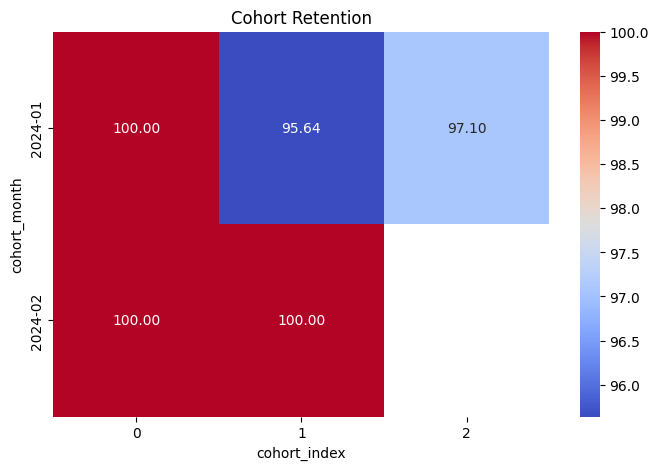

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(retention_pct, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cohort Retention")
plt.show()

In [ ]:
Goal:
👉 Predict: High-value user (Yes / No)
Based on: behavior, transactions
Can we identify users likely to become high-value based on past behavior?

In [75]:
#Step 1: Create User-Level Dataset
user_df = df.groupby('user_id', as_index=False).agg(
    total_spend=('amount', 'sum'),
    total_transactions=('transaction_id', 'count'),
    avg_transaction=('amount', 'mean')
)

In [77]:
#Step 2: Create Target Variable- Define high-value user
user_df['high_value'] = (user_df['total_spend'] >= 20000).astype(int)

In [78]:
user_df.head()

,user_id,total_spend,total_transactions,avg_transaction,high_value
0,1,10906,14,779.000000,0
1,2,10971,10,1097.100000,0
2,3,7999,9,888.777778,0
3,4,9533,10,953.300000,0
4,5,16847,15,1123.133333,0


In [79]:
#Step 3: Feature Selection
X = user_df[['total_transactions', 'avg_transaction']]
y = user_df['high_value']

In [84]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.0 MB 16.7 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.0 MB 10.6 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 9.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 7.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 6.7 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.5 MB 6.1 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/36.5 MB 6.7 MB/s eta 0:00:06
   ---- ----------------------------------- 3.9/36.5 MB 6.0 MB/s eta 0:00:06
   ----- ---------------------------------- 4.7/36.5 MB 5.6 MB/s eta 0:00:06
   ------ ----------

In [85]:
#Step 4: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
#Step 5: Train Model (Simple & Safe)- going to use logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [87]:
#Step 6: Predictions 
y_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 1.0
Precision: 0.0
Recall: 0.0


C:\Users\gdsid\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gdsid\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [89]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
I built a simple classification model using user transaction features to identify high-value users and evaluated it using precision and recall.

In [91]:
importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
importance

,feature,coefficient
0,total_transactions,1.676046
1,avg_transaction,0.024424


In [92]:
user_df['txn_frequency'] = user_df['total_transactions'] / 90

In [ ]:
Built a machine learning model to identify high-value users using transaction-level features, improving user segmentation and targeting